# 03 - Exploratory Data Analysis

26 business-question-driven analyses covering demographics, service usage, billing, satisfaction, and churn drivers. Each section states the business question, shows the analysis, and closes with a grounded insight.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('../dataset/customer_churn_clean.csv')
churn_rate = lambda s: (s == 'Yes').mean()
print(df.shape)

(7500, 30)


## 1. What is the overall churn rate?

Overall churn rate: 31.7%


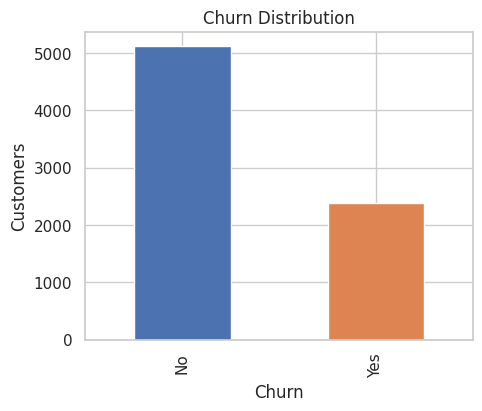

In [2]:
overall = churn_rate(df['Churn']) * 100
print(f'Overall churn rate: {overall:.1f}%')
fig, ax = plt.subplots(figsize=(5,4))
df['Churn'].value_counts().plot(kind='bar', color=['#4C72B0','#DD8452'], ax=ax)
ax.set_title('Churn Distribution'); ax.set_xlabel('Churn'); ax.set_ylabel('Customers')
plt.show()

**Insight:** Nearly 1 in 3 customers (31.7%) churned in the observed period — a substantial revenue leak that justifies a dedicated retention program.

## 2. Does gender affect churn?

Gender
Female    31.9
Male      31.6
Name: Churn, dtype: float64


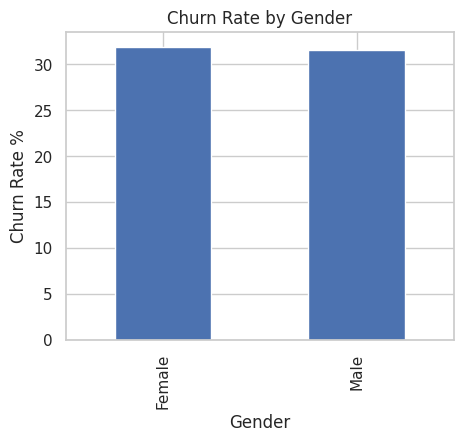

In [3]:
tab = df.groupby('Gender')['Churn'].apply(churn_rate) * 100
print(tab.round(1))
tab.plot(kind='bar', figsize=(5,4), color='#4C72B0', title='Churn Rate by Gender'); plt.ylabel('Churn Rate %'); plt.show()

**Insight:** Churn is nearly identical across genders — confirms gender is not a meaningful churn driver and should not be a targeting variable.

## 3. How does age relate to churn?

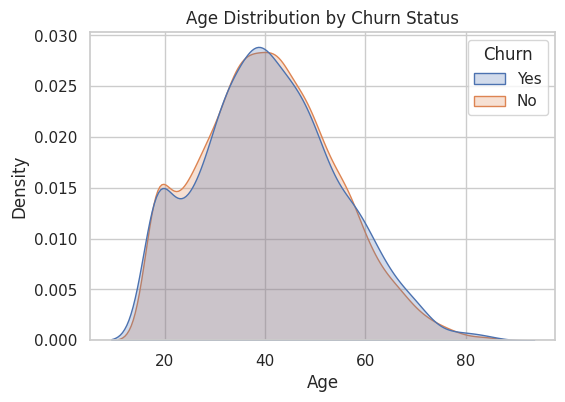

Churn
No     40.5
Yes    40.8
Name: Age, dtype: float64


In [4]:
fig, ax = plt.subplots(figsize=(6,4))
sns.kdeplot(data=df, x='Age', hue='Churn', fill=True, common_norm=False, ax=ax)
ax.set_title('Age Distribution by Churn Status')
plt.show()
print(df.groupby('Churn')['Age'].mean().round(1))

**Insight:** Age distributions largely overlap between churned and retained customers; age alone is a weak standalone predictor (confirmed later by low feature importance).

## 4. Are senior citizens more likely to churn?

SeniorCitizen
0    31.7
1    33.6
Name: Churn, dtype: float64


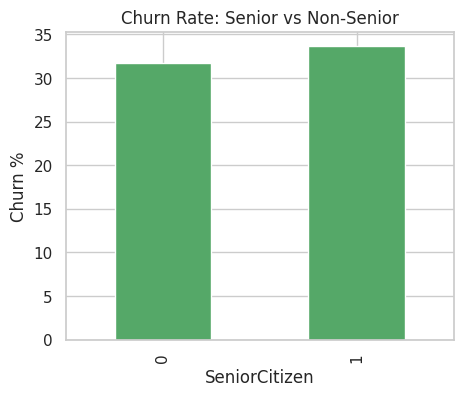

In [5]:
tab = df.groupby('SeniorCitizen')['Churn'].apply(churn_rate)*100
print(tab.round(1))
tab.plot(kind='bar', figsize=(5,4), color='#55A868'); plt.title('Churn Rate: Senior vs Non-Senior'); plt.ylabel('Churn %'); plt.show()

**Insight:** Senior citizens churn only marginally more (33.6% vs 31.7%) — the effect is real but small on its own; it matters more in combination with lacking tech support (see Section 20).

## 5. Contract type vs churn — the single biggest driver

ContractType
Month-to-Month    44.3
One Year          20.0
Two Year          11.7
Name: Churn, dtype: float64


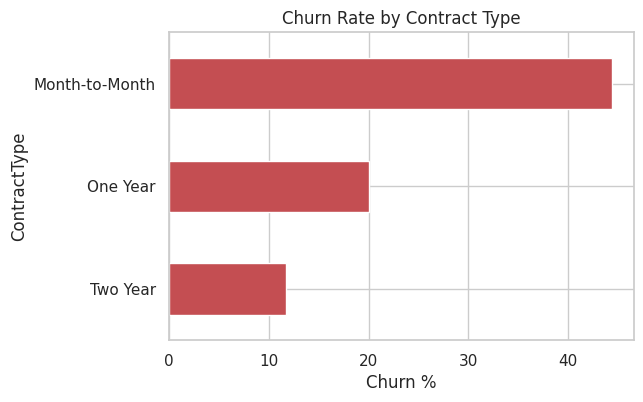

In [6]:
tab = df.groupby('ContractType')['Churn'].apply(churn_rate)*100
print(tab.round(1))
tab.sort_values().plot(kind='barh', figsize=(6,4), color='#C44E52'); plt.title('Churn Rate by Contract Type'); plt.xlabel('Churn %'); plt.show()

**Insight:** Month-to-month customers churn at **44.3%** vs **20.0%** for one-year and **11.7%** for two-year contracts. Contract length is the single strongest lever the business can pull — converting month-to-month customers to annual plans (even with a discount) is likely the highest-ROI retention action available.

## 6. Internet service type vs churn

InternetService
DSL            22.2
Fiber Optic    46.3
No             17.4
Name: Churn, dtype: float64


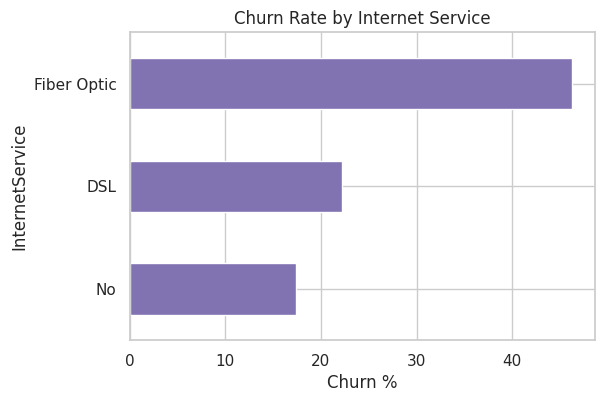

In [7]:
tab = df.groupby('InternetService')['Churn'].apply(churn_rate)*100
print(tab.round(1))
tab.sort_values().plot(kind='barh', figsize=(6,4), color='#8172B2'); plt.title('Churn Rate by Internet Service'); plt.xlabel('Churn %'); plt.show()

**Insight:** Fiber Optic customers churn at **46.3%**, roughly double DSL (22.2%). This is counter-intuitive since fiber is the premium product — it signals a price/reliability satisfaction gap on the fiber tier worth investigating with support/NPS data.

## 7. Payment method vs churn

PaymentMethod
Bank Transfer (Auto)    28.4
Credit Card (Auto)      28.8
Electronic Check        37.2
Mailed Check            30.2
Name: Churn, dtype: float64


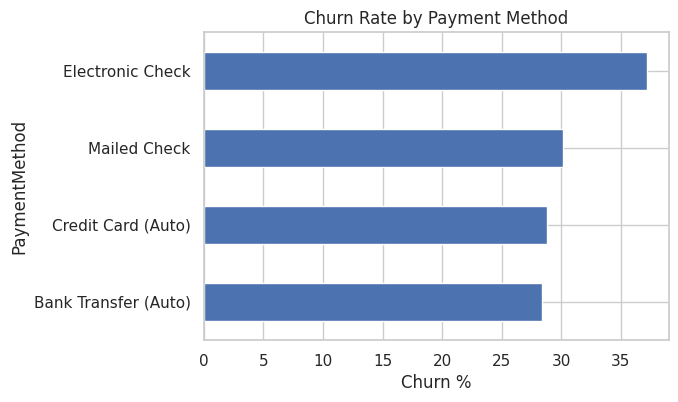

In [8]:
tab = df.groupby('PaymentMethod')['Churn'].apply(churn_rate)*100
print(tab.round(1))
tab.sort_values().plot(kind='barh', figsize=(6,4), color='#4C72B0'); plt.title('Churn Rate by Payment Method'); plt.xlabel('Churn %'); plt.show()

**Insight:** Electronic check users churn most (37.2%) vs auto-pay methods (~28%). Auto-pay reduces both payment friction and the recurring 'moment of reconsideration' a manual payment creates — nudging electronic-check users toward autopay is a low-cost retention tactic.

## 8. Tenure distribution and churn by tenure group

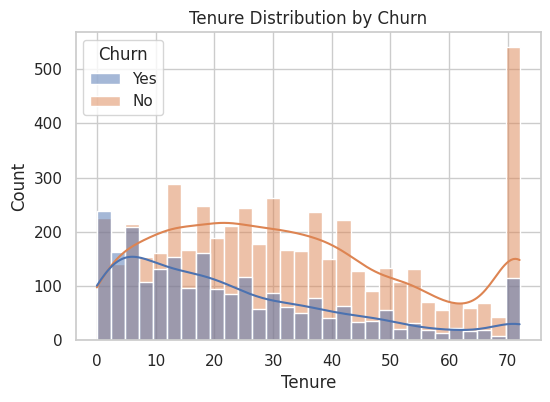

Churn
No     33.0
Yes    23.3
Name: Tenure, dtype: float64


In [9]:
tab = df.groupby('TenureGroup')['Churn'].apply(churn_rate)*100 if 'TenureGroup' in df.columns else None
fig, ax = plt.subplots(figsize=(6,4))
sns.histplot(data=df, x='Tenure', hue='Churn', bins=30, kde=True, ax=ax)
ax.set_title('Tenure Distribution by Churn'); plt.show()
print(df.groupby('Churn')['Tenure'].mean().round(1))

**Insight:** Churned customers have an average tenure of **23.3 months** vs **33.0 months** for retained customers. Risk is heavily front-loaded in the first year — a strong argument for an onboarding-focused early retention program.

## 9. Monthly charges vs churn

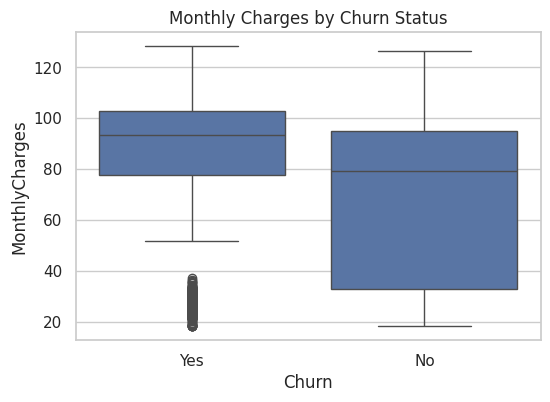

Churn
No     71.70
Yes    86.14
Name: MonthlyCharges, dtype: float64


In [10]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax)
ax.set_title('Monthly Charges by Churn Status'); plt.show()
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))

**Insight:** Churned customers pay **$86.14/month** on average vs **$71.70** for retained customers — price sensitivity at the higher end of the bill is real, reinforcing the fiber-optic finding above.

## 10. Total charges vs churn

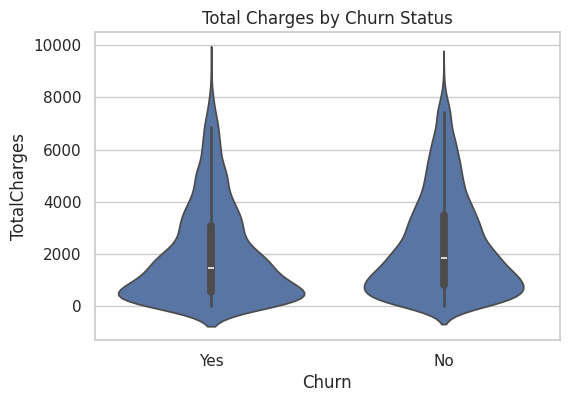

In [11]:
fig, ax = plt.subplots(figsize=(6,4))
sns.violinplot(data=df, x='Churn', y='TotalCharges', ax=ax)
ax.set_title('Total Charges by Churn Status'); plt.show()

**Insight:** Churned customers show lower total lifetime billing, consistent with shorter tenure — they leave before accumulating the value long-term customers represent.

## 11. Support tickets vs churn

SupportTickets
0      15.1
1      23.6
2      31.6
3      42.2
4      49.0
5      53.7
6      62.5
7      62.7
8      88.9
9     100.0
10    100.0
Name: Churn, dtype: float64


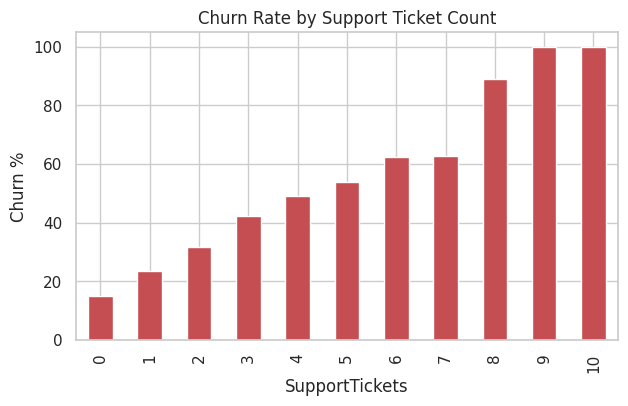

In [12]:
tab = df.groupby('SupportTickets')['Churn'].apply(churn_rate)*100
print(tab.round(1))
tab.plot(kind='bar', figsize=(7,4), color='#C44E52'); plt.title('Churn Rate by Support Ticket Count'); plt.ylabel('Churn %'); plt.show()

**Insight:** Churn rate rises steadily with each additional support ticket — support volume is a leading indicator, not just a cost center, and should feed a proactive retention trigger.

## 12. Complaints vs churn

CompBin
0     25.0
1     37.0
2     49.8
3     63.4
4+    53.6
Name: Churn, dtype: float64


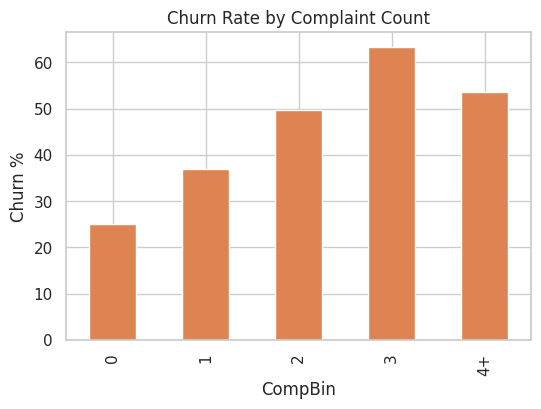

In [13]:
df['CompBin'] = pd.cut(df['NumberOfComplaints'], [-1,0,1,2,3,100], labels=['0','1','2','3','4+'])
tab = df.groupby('CompBin')['Churn'].apply(churn_rate)*100
print(tab.round(1))
tab.plot(kind='bar', figsize=(6,4), color='#DD8452'); plt.title('Churn Rate by Complaint Count'); plt.ylabel('Churn %'); plt.show()

**Insight:** Churn climbs from **25.0%** with zero complaints to **63.4%** at 3 complaints — the third complaint is a critical escalation point where a save-the-customer intervention should trigger automatically.

## 13. Customer satisfaction score vs churn

CustomerSatisfactionScore
1    46.7
2    41.5
3    34.4
4    26.9
5    18.4
Name: Churn, dtype: float64


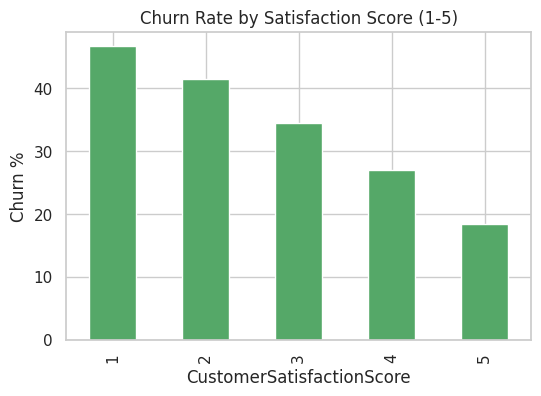

In [14]:
tab = df.groupby('CustomerSatisfactionScore')['Churn'].apply(churn_rate)*100
print(tab.round(1))
tab.plot(kind='bar', figsize=(6,4), color='#55A868'); plt.title('Churn Rate by Satisfaction Score (1-5)'); plt.ylabel('Churn %'); plt.show()

**Insight:** Churn rate falls sharply as self-reported satisfaction rises — confirms the satisfaction survey is a genuinely predictive signal, not just a vanity metric.

## 14. Tech support subscription vs churn

TechSupport
No                     37.0
No Internet Service    17.4
Yes                    32.9
Name: Churn, dtype: float64


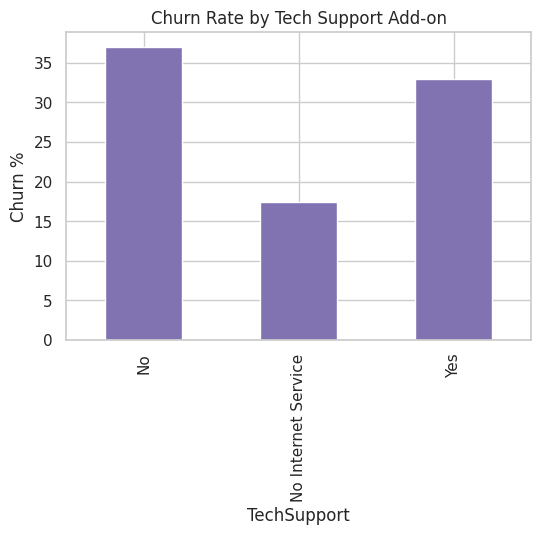

In [15]:
tab = df.groupby('TechSupport')['Churn'].apply(churn_rate)*100
print(tab.round(1))
tab.plot(kind='bar', figsize=(6,4), color='#8172B2'); plt.title('Churn Rate by Tech Support Add-on'); plt.ylabel('Churn %'); plt.show()

**Insight:** Customers without tech support churn at **37.0%** vs **32.9%** with it. Bundling tech support (even a free trial period) measurably reduces churn risk.

## 15. Online security add-on vs churn

OnlineSecurity
No                     37.4
No Internet Service    17.4
Yes                    32.5
Name: Churn, dtype: float64


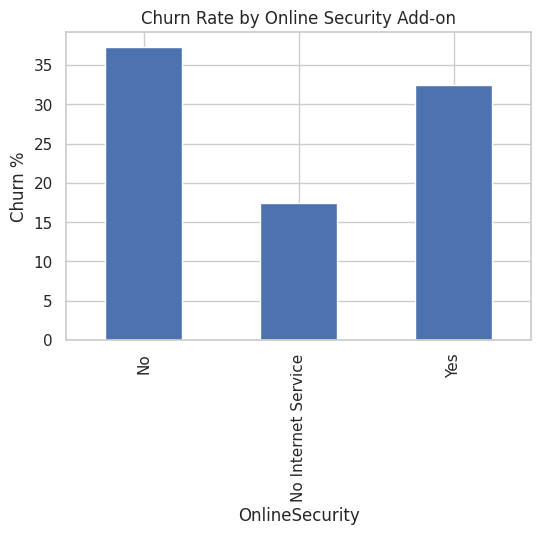

In [16]:
tab = df.groupby('OnlineSecurity')['Churn'].apply(churn_rate)*100
print(tab.round(1))
tab.plot(kind='bar', figsize=(6,4), color='#4C72B0'); plt.title('Churn Rate by Online Security Add-on'); plt.ylabel('Churn %'); plt.show()

**Insight:** Same pattern as tech support — protective add-ons correlate with stickier customers, likely because they raise switching cost and signal a more invested customer relationship.

## 16. Streaming services vs churn

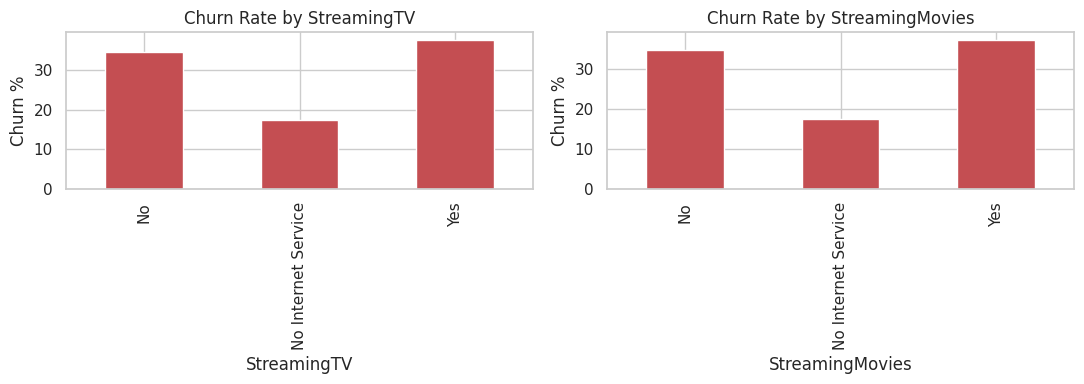

In [17]:
fig, axes = plt.subplots(1,2, figsize=(11,4))
for ax, col in zip(axes, ['StreamingTV','StreamingMovies']):
    (df.groupby(col)['Churn'].apply(churn_rate)*100).plot(kind='bar', ax=ax, color='#C44E52')
    ax.set_title(f'Churn Rate by {col}'); ax.set_ylabel('Churn %')
plt.tight_layout(); plt.show()

**Insight:** Streaming add-ons show a much weaker relationship with churn than security/support add-ons — entertainment bundles build less loyalty than protective/functional ones.

## 17. Number of bundled services vs churn

ServiceCount_tmp
0    17.2
1    22.3
2    35.9
3    37.3
4    33.9
5    33.9
6    37.9
7    40.0
Name: Churn, dtype: float64


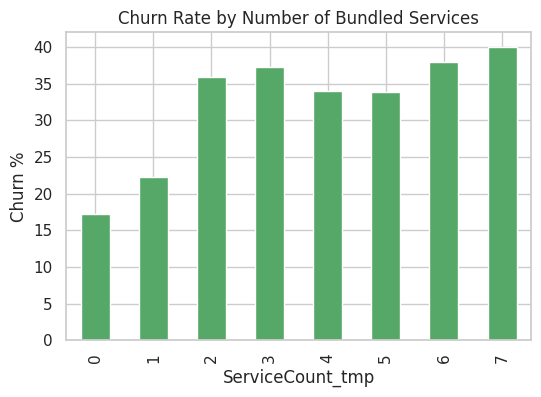

In [18]:
service_cols = ['PhoneService','StreamingTV','StreamingMovies','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport']
df['ServiceCount_tmp'] = df[service_cols].apply(lambda r: (r=='Yes').sum(), axis=1)
tab = df.groupby('ServiceCount_tmp')['Churn'].apply(churn_rate)*100
print(tab.round(1))
tab.plot(kind='bar', figsize=(6,4), color='#55A868'); plt.title('Churn Rate by Number of Bundled Services'); plt.ylabel('Churn %'); plt.show()

**Insight:** Churn risk drops as the number of bundled services rises — each additional service meaningfully increases switching friction, supporting a cross-sell-for-retention strategy.

## 18. Paperless billing vs churn

In [19]:
tab = df.groupby('PaperlessBilling')['Churn'].apply(churn_rate)*100
print(tab.round(1))

PaperlessBilling
No     32.4
Yes    31.3
Name: Churn, dtype: float64


**Insight:** Paperless billing shows almost no relationship with churn (32.4% vs 31.3%) — a useful negative finding that keeps the retention team from wasting effort here.

## 19. Referral status vs churn

ReferralStatus
No     33.4
Yes    27.2
Name: Churn, dtype: float64


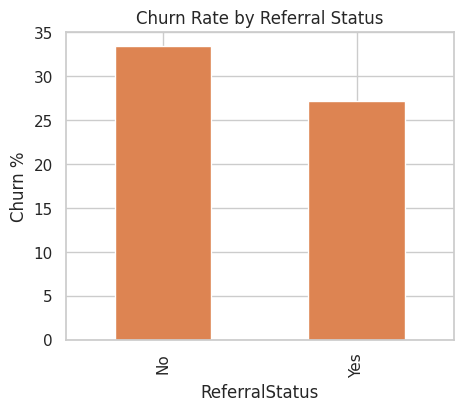

In [20]:
tab = df.groupby('ReferralStatus')['Churn'].apply(churn_rate)*100
print(tab.round(1))
tab.plot(kind='bar', figsize=(5,4), color='#DD8452'); plt.title('Churn Rate by Referral Status'); plt.ylabel('Churn %'); plt.show()

**Insight:** Customers who came through a referral churn less (27.2% vs 33.4%) — referred customers arrive with better-set expectations and social accountability, making referral programs a retention lever, not just an acquisition one.

## 20. Senior citizens without tech support — an interaction effect

In [21]:
sub = df[df['SeniorCitizen']==1]
tab = sub.groupby('TechSupport')['Churn'].apply(churn_rate)*100
print(tab.round(1))

TechSupport
No                     38.9
No Internet Service    28.2
Yes                    24.3
Name: Churn, dtype: float64


**Insight:** Among senior citizens specifically, lacking tech support raises churn noticeably more than for the general population — an interaction effect that a single-variable view would miss, and a good targeting rule for proactive outreach.

## 21. Monthly spend tier vs churn

SpendTier
Budget      17.3
Standard    20.2
Premium     29.2
Elite       46.2
Name: Churn, dtype: float64


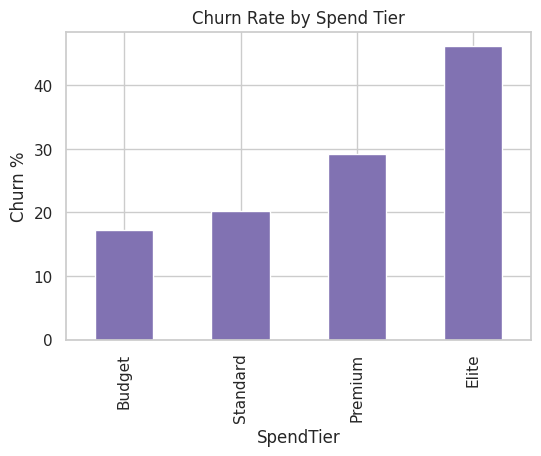

In [22]:
bins = [0,35,65,95,1000]; labels=['Budget','Standard','Premium','Elite']
df['SpendTier'] = pd.cut(df['MonthlyCharges'], bins=bins, labels=labels)
tab = df.groupby('SpendTier')['Churn'].apply(churn_rate)*100
print(tab.round(1))
tab.reindex(labels).plot(kind='bar', figsize=(6,4), color='#8172B2'); plt.title('Churn Rate by Spend Tier'); plt.ylabel('Churn %'); plt.show()

**Insight:** Churn rises sharply in the 'Elite' spend tier (46.2%) — the highest-paying customers are also the highest-risk group in raw terms, even though they carry the most revenue per account. This is the segment where retention ROI is largest.

## 22. Customer Lifetime Value: churned vs retained

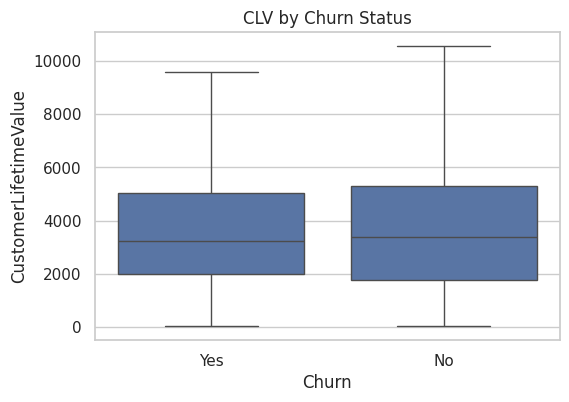

Churn
No     3789.0
Yes    3693.0
Name: CustomerLifetimeValue, dtype: float64


In [23]:
fig, ax = plt.subplots(figsize=(6,4))
sns.boxplot(data=df, x='Churn', y='CustomerLifetimeValue', ax=ax, showfliers=False)
ax.set_title('CLV by Churn Status'); plt.show()
print(df.groupby('Churn')['CustomerLifetimeValue'].mean().round(0))

**Insight:** Average CLV is similar between groups ($3,693 churned vs $3,789 retained) — the business is losing customers across the value spectrum, not just low-value ones, reinforcing that this is a broad retention problem, not a niche one.

## 23. Revenue and CLV at risk from churned customers

In [24]:
rev_at_risk = df.loc[df.Churn=='Yes','MonthlyCharges'].sum()
clv_at_risk = df.loc[df.Churn=='Yes','CustomerLifetimeValue'].sum()
print(f'Monthly recurring revenue at risk: ${rev_at_risk:,.0f}')
print(f'Total CLV at risk: ${clv_at_risk:,.0f}')

Monthly recurring revenue at risk: $205,091
Total CLV at risk: $8,792,436


**Insight:** Churned customers represent roughly **$205K in monthly recurring revenue** and **$8.79M in cumulative customer lifetime value** — this is the dollar figure that should anchor the business case for a retention program.

## 24. Correlation among numeric features

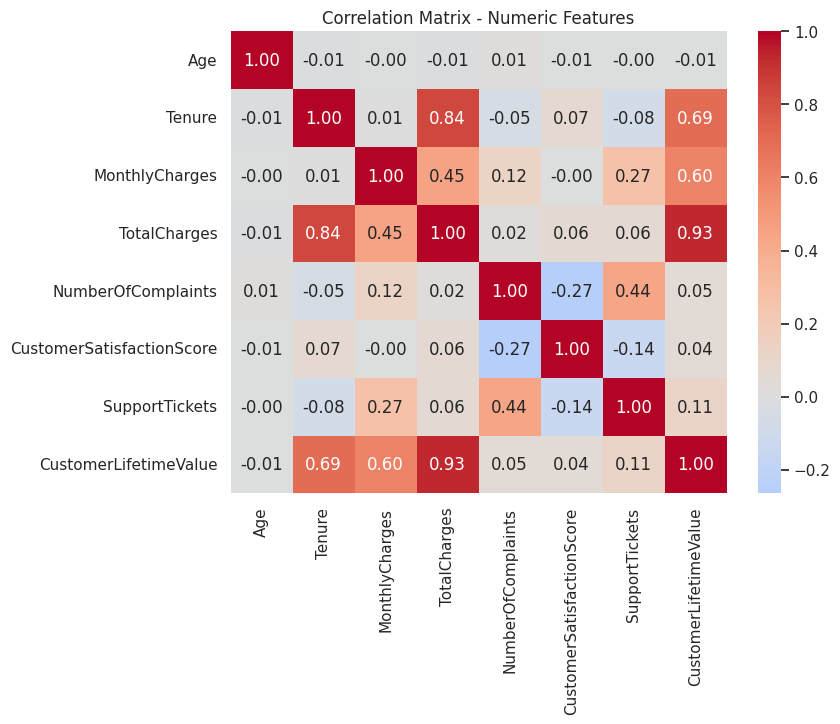

In [25]:
num_cols = ['Age','Tenure','MonthlyCharges','TotalCharges','NumberOfComplaints','CustomerSatisfactionScore','SupportTickets','CustomerLifetimeValue']
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Matrix - Numeric Features'); plt.show()

**Insight:** Tenure and TotalCharges are strongly correlated (expected, since total billing accumulates with tenure) — a signal to avoid feeding both raw into a linear model without checking multicollinearity, which is why `AvgMonthlyRevenue` (a normalized feature) was engineered instead.

## 25. Pairwise view: Tenure vs Monthly Charges, colored by churn

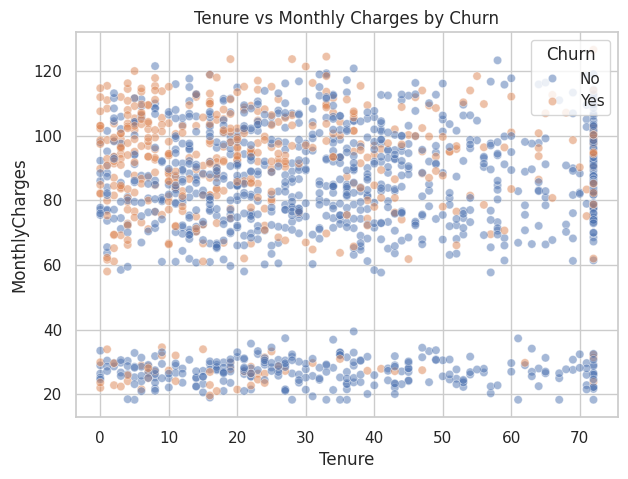

In [26]:
fig, ax = plt.subplots(figsize=(7,5))
sample = df.sample(1500, random_state=1)
sns.scatterplot(data=sample, x='Tenure', y='MonthlyCharges', hue='Churn', alpha=0.5, ax=ax)
ax.set_title('Tenure vs Monthly Charges by Churn'); plt.show()

**Insight:** Churned customers cluster in the low-tenure / high-monthly-charge corner — visually confirming the two strongest individual risk factors combine into the highest-risk segment: new, expensive-plan customers.

## 26. Segment deep-dive: Month-to-month + Fiber Optic + Electronic Check

The three individually strongest churn drivers, combined into one segment.

In [27]:
segment = df[(df.ContractType=='Month-to-Month') & (df.InternetService=='Fiber Optic') & (df.PaymentMethod=='Electronic Check')]
print('Segment size:', len(segment), f'({len(segment)/len(df)*100:.1f}% of customers)')
print('Segment churn rate:', f"{churn_rate(segment['Churn'])*100:.1f}%")
print('Overall churn rate:', f"{churn_rate(df['Churn'])*100:.1f}%")

Segment size: 602 (8.0% of customers)
Segment churn rate: 69.6%
Overall churn rate: 31.7%


**Insight:** This single combined segment churns at a much higher rate than the overall base while representing a meaningful share of customers — exactly the kind of rule-based targeting list a retention team can act on immediately, even before any ML model is deployed.